In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import seaborn as sns


## Carregar o Dataset

In [32]:
df = pd.read_csv("fraude.csv")
df.head()


,Valor,Periodo,Classe
0,2500,Diurno,Normal
1,1500,Diurno,Normal
2,700,Diurno,Normal
3,3700,Diurno,Normal
4,5600,Diurno,Normal


## Drop  de linhas e inserção de dados faltantes

In [33]:

expected_cols = {"Valor", "Periodo", "Classe"}
if not expected_cols.issubset(df.columns):
    raise ValueError(f"Colunas esperadas: {expected_cols}. Encontrado: {set(df.columns)}")

data = df.copy()

data = data.dropna(subset=["Classe"])

if data["Valor"].isna().any():
    data["Valor"] = data["Valor"].fillna(data["Valor"].median())
if data["Periodo"].isna().any():
    data["Periodo"] = data["Periodo"].fillna("Desconhecido")

print("Contagem por classe:\n", data["Classe"].value_counts())



Contagem por classe:
 Classe
Normal    32
Fraude     6
Name: count, dtype: int64


## Pré-processamento

In [34]:
numeric_features = ["Valor"]
categorical_features = ["Periodo"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X = data[numeric_features + categorical_features]
y = data["Classe"].astype(str)

X_processed = preprocessor.fit_transform(X)

cat_names = preprocessor.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_names)
print("Features processadas (ordem):", feature_names)
print("X_processed shape:", X_processed.shape)


Features processadas (ordem): ['Valor', 'Periodo_Diurno', 'Periodo_Noturno']
X_processed shape: (38, 3)


## Divisão do Conjunto para treino

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.25, random_state=42, stratify=y
)
print("Treino:", X_train.shape, "Teste:", X_test.shape)


Treino: (28, 3) Teste: (10, 3)


## Random Forest

In [36]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)


## Métricas

In [37]:
acc = accuracy_score(y_test, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
cm = confusion_matrix(y_test, y_pred, labels=["Fraude", "Normal"])
report = classification_report(y_test, y_pred)

print("Random Forest - Desempenho (teste)")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro): {rec:.4f}")
print(f"F1 (macro): {f1:.4f}")
print("\nMatriz de Confusão (labels = ['Fraude','Normal']):\n", cm)
print("\nClassification Report:\n", report)


Random Forest - Desempenho (teste)
Accuracy: 0.9000
Precision (macro): 0.8333
Recall (macro): 0.9375
F1 (macro): 0.8667

Matriz de Confusão (labels = ['Fraude','Normal']):
 [[2 0]
 [1 7]]

Classification Report:
               precision    recall  f1-score   support

      Fraude       0.67      1.00      0.80         2
      Normal       1.00      0.88      0.93         8

    accuracy                           0.90        10
   macro avg       0.83      0.94      0.87        10
weighted avg       0.93      0.90      0.91        10



## Plot

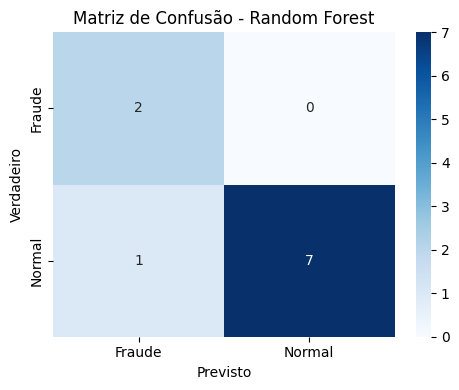

In [38]:
labels = ["Fraude", "Normal"]
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Previsto")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.show()


## Curva ROC e AUC

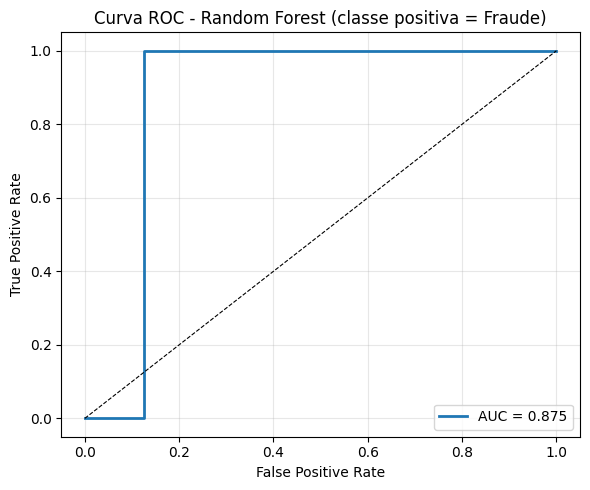

AUC: 0.8750


In [39]:

y_test_bin = (y_test == "Fraude").astype(int)

idx_fraude = list(rf.classes_).index("Fraude")
y_score = y_proba[:, idx_fraude]

fpr, tpr, thresholds = roc_curve(y_test_bin, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest (classe positiva = Fraude)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC: {roc_auc:.4f}")


## Importancia das Features

           feature  importance
0            Valor    0.853209
1   Periodo_Diurno    0.085080
2  Periodo_Noturno    0.061711


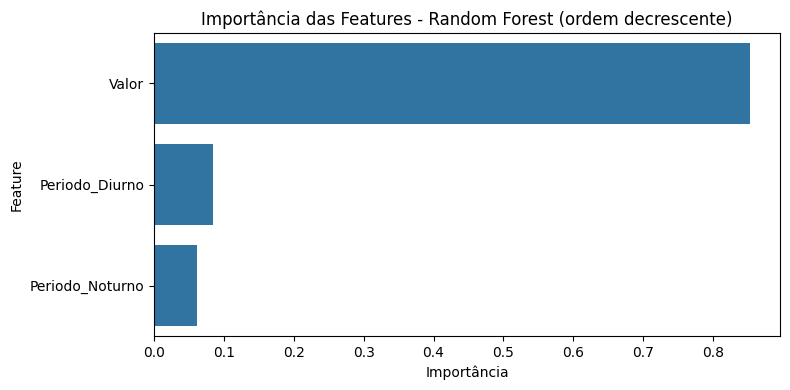

In [40]:
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print(feat_imp)

plt.figure(figsize=(8, max(4, 0.4 * len(feat_imp))))
sns.barplot(x="importance", y="feature", data=feat_imp, orient="h")
plt.title("Importância das Features - Random Forest (ordem decrescente)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Salvar métricas

In [41]:
outdir = Path("results")
figdir = outdir / "figures"
figdir.mkdir(parents=True, exist_ok=True)

with open(outdir / "metrics_rf.txt", "w") as f:
    f.write("Random Forest - Métricas (conjunto de teste)\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Precision (macro): {prec:.4f}\n")
    f.write(f"Recall (macro): {rec:.4f}\n")
    f.write(f"F1 (macro): {f1:.4f}\n\n")
    f.write("Matriz de Confusão (labels = ['Fraude','Normal']):\n")
    f.write(np.array2string(cm))
    f.write("\n\nClassification Report:\n")
    f.write(report)
    f.write(f"\nAUC: {roc_auc:.4f}\n\n")
    f.write("Importância das features (ordem decrescente):\n")
    f.write(feat_imp.to_string(index=False))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Previsto")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão - Random Forest")
plt.tight_layout()
plt.savefig(figdir / "confusion_matrix_rf.png", dpi=200)
plt.close()

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(figdir / "roc_rf.png", dpi=200)
plt.close()

plt.figure(figsize=(8, max(4, 0.4 * len(feat_imp))))
sns.barplot(x="importance", y="feature", data=feat_imp, orient="h")
plt.title("Importância das Features - Random Forest")
plt.tight_layout()
plt.savefig(figdir / "feature_importances_rf.png", dpi=200)
plt.close()

print("Métricas e figuras salvas em:", outdir.resolve())


Métricas e figuras salvas em: /content/results
